<a href="https://colab.research.google.com/github/kuiper2000/RC_model/blob/main/CWA_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

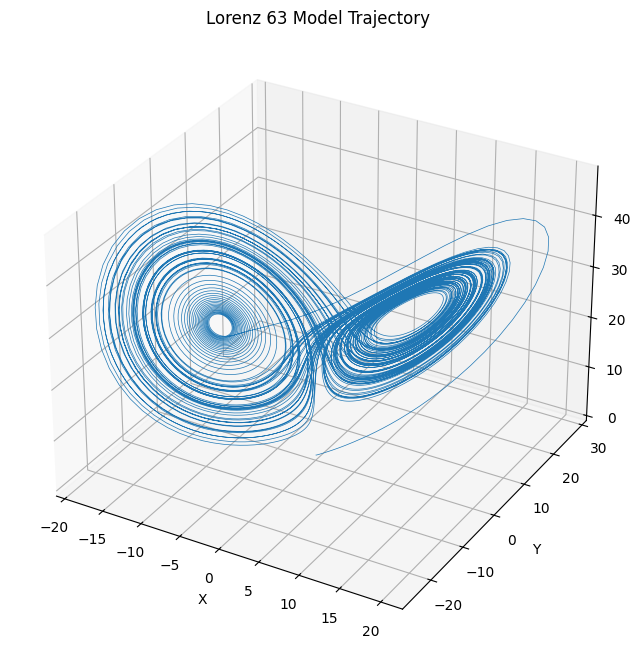

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters for the Lorenz system
sigma = 10.0
rho   = 28.0
beta  = 8.0 / 3.0

# Define the Lorenz system of differential equations
def lorenz63(t, state):
    x, y, z = state
    dxdt    = sigma * (y - x)
    dydt    = x * (rho - z) - y
    dzdt    = x * y - beta * z
    return [dxdt, dydt, dzdt]

# Initial state and time settings
initial_state = [0.0, 0.1, 0.0]
t_start       = 0.0
t_end         = 10000 * 0.01  # 10000 steps with a time increment of 0.01
t_eval        = np.arange(t_start, t_end, 0.01)

# Integrate the Lorenz system
solution = solve_ivp(lorenz63, [t_start, t_end], initial_state, t_eval=t_eval, method='RK45')

# Extract the results
x, y, z = solution.y

# Plot results
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw=0.5)
ax.set_title("Lorenz 63 Model Trajectory")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

In [2]:
from scipy import linalg
import numpy as np
import matplotlib.pyplot as plt


class reservoir():
  def __init__(self, trainLen=int, validLen=int, initLen=int, inSize=int, outSize = int,
                 resSize = int, a = float, seed = int,
                 reg=float):
    self.trainLen  = trainLen    # length for training
    self.validLen  = validLen    # length for validation
    self.initLen   = initLen      # length for initialization (spinup is necessaary to form the reservoir state)
    self.inSize    = inSize       # input variable dimension
    self.outSize   = outSize      # output variable dimension
    self.resSize   = resSize      # reservoir size (how many past states are used)
    self.a         = a            # leaking rate
    self.seed      = seed         # experiment number (any number bigger than 0, if seed=0, randomly initialized)
    self.reg       = reg          # regularization intensity (regid by default)


  def training(self, data): # data should have a dimension of [time X variable]
    if self.seed==0:
      np.random.seed()
    else:
      np.random.seed(self.seed)

    # preparing regression coefficient
    Win   = (np.random.rand(self.resSize,1+self.inSize) - 0.5) * 1
    W     = np.random.rand(self.resSize,self.resSize) - 0.5
    # normalizing and setting spectral radius (correct, slow):
    #print('Computing spectral radius...')
    rhoW  = max(abs(linalg.eig(W)[0]))
    #print('done.')
    W    *= 1.25 / rhoW

    # allocated memory for the design matrix (collected states including the input from current step and past step)
    X     = np.zeros((1+self.inSize+self.resSize,self.trainLen-self.initLen))
    # set the corresponding target matrix directly
    Yt    = data[self.initLen+1:self.trainLen+1, :].T

    # rewrite this a batch
    # run the reservoir with the data and collect X
    x = np.zeros((self.resSize,1))  # input from current time step
    for t in range(self.trainLen):
        u    = data[t,:]
        u    = np.reshape(u,[self.inSize,1])
        unit = np.ones((1,1))
        x    = (1-self.a)*x + self.a*np.tanh( np.dot( Win, np.vstack((1,u))) + np.dot( W, x ) )

        # after initialization step, stacking the input from current step and latent state together
        if t >= self.initLen:
            X[:,t-self.initLen] = np.vstack((1,u,x))[:,0]

    # train the output layer with Normal Equation method (+ rigid regularization)
    Wout = linalg.solve( np.dot(X,X.T) + self.reg*np.eye(1+self.inSize+self.resSize), np.dot(X,Yt.T) ).T
    #return all variables at t=trainLen
    return x, Win, W, Wout

  def training_validation(self,data):
    # training the model
    x, Win, W, Wout = self.training(data)

    # run the trained ESN in a generative mode. no need to initialize here,
    # because x is initialized with training data and we continue from there.
    Y        = np.zeros((self.outSize,self.validLen)) # the forecast value
    Y[:,0]   = data[self.trainLen,:]
    u        = data[self.trainLen,:]                 # the input for steps at trainLen
    u        = np.reshape(u,[self.inSize,1])
    unit     = np.ones((1,1))
    x_record = x.copy()
    for t in range(self.validLen-1):
        x        = (1-self.a)*x + self.a*np.tanh( np.dot( Win, np.vstack((unit,u)) ) + np.dot( W, x ) )
        y        = np.dot( Wout, np.vstack((1,u,x)) )
        Y[:,t+1] = np.squeeze(y)
        # generative mode:
        u        = y                                   # using the forecast value as the next time step input
        u        = np.reshape(u,[self.inSize,1])
        ## this would be a predictive mode:
        #u = data[trainLen+t+1]


    # targeting specific lead
    errorLen = self.validLen
    #print(data[self.trainLen+errorLen].shape)
    mse      = sum( np.square( data[self.trainLen:self.trainLen+errorLen] - np.transpose(Y[:,0:errorLen]) ) ) / errorLen

    return Y, x_record, Win, W, Wout, mse


  def prediction(self,data,Win,W,Wout,ensemble_size=1000,forecast_time=10):
    dim_t, dim_var = data.shape
    x              = np.zeros((self.resSize,1))
    Y              = np.zeros((self.resSize,forecast_time))
    unit           = np.ones((1,1))
    # initialization to generate x
    for t in range(dim_t-1):
        u    = data[t,:]
        u    = np.reshape(u,[self.inSize,1])
        unit = np.ones((1,1))
        x    = (1-self.a)*x + self.a*np.tanh( np.dot( Win, np.vstack((1,u))) + np.dot( W, x ))

    data_ensemble      = np.zeros((self.inSize,ensemble_size))
    data_ensemble[:,0] = data[-1,:]       # the first member has no perturbation
    for i in range(self.inSize):       # other members have perturbation
        data_ensemble[i,1:] = data[-1,i]+np.random.normal(loc=0.0, scale=0.05, size=ensemble_size-1)

    u                  = data_ensemble
    u                  = np.reshape(u,[self.inSize,ensemble_size])
    x                  = np.repeat(x, ensemble_size, axis=1)      # repeat the hidden state (identical for all ensemble)
    Y                  = np.zeros((self.inSize,ensemble_size,forecast_time))  # array for saving forecast results
    Y[:,:,0]           = u
    unit               = np.ones((1,ensemble_size))
    for t in range(forecast_time-1):
        x = (1-self.a)*x + self.a*np.tanh( np.dot( Win, np.vstack((unit,u)) ) + np.dot( W, x ) )
        y = np.dot( Wout, np.vstack((unit,u,x)))
        Y[:,:,t+1] = y
        # generative mode:
        u = y
        u = np.reshape(u,[self.inSize,ensemble_size])

    return Y

In [7]:
# from Reservoir_Computing import reservoir


# Dictionary the models
# d is used to save the pre-trained models
# 100 different models are saved for the following prediction task
model_size = 100 # how many different models are trained
d          = {}
count      = 0
# stack data
data               = np.array(np.vstack((x,y,z)))
dim_var, dim_time  = data.shape

while True:
    a                  = np.random.choice([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9], 1, replace=False) # leaking rate
    data_length        = np.random.choice(range(5000,7000), 1, replace=False)                      # [5000,7000] steps as the minimum/maximum length for traning the model
    resSize            = np.random.choice(range(50,100), 1,  replace=False)                        # reservoir size (bigger leads to more complicated model)
    validLen           = 10                                                                        # using the subsequent 10 steps for validation. e.g., training ends at 500, then use 501-510 for validation
    model              = reservoir(trainLen= int(data_length), validLen= validLen, initLen= 10, inSize=int(dim_var), outSize = int(dim_var),
                                   resSize = int(resSize),           a = a,          seed = 0,
                                       reg = 1e1)
    Y, x_record, Win, W, Wout,mse   = model.training_validation(data.T)

    if (np.mean(mse[:3]) < 0.02) & (count<model_size):
        # To keep a model, the mean MSE (x,y and z) at the validation set should be smaller than 0.02
        d["model{0}".format(count)]    = model, Win, W, Wout, "a="+str(a), "resSize="+str(resSize), "testLen="+str(validLen)
        count = count+1
        print(count)
        print(np.mean(mse[:3]))
    elif count>=model_size:
        break

/tmp/ipykernel_8649/2171479993.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  model              = reservoir(trainLen= int(data_length), validLen= validLen, initLen= 10, inSize=int(dim_var), outSize = int(dim_var),
/tmp/ipykernel_8649/2171479993.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  resSize = int(resSize),           a = a,          seed = 0,


1
0.008192758940237558
2
0.01071870388953784
3
0.007788290573182244
4
0.019749022019283826
5
0.017985608019066457
6
0.0031928801722896694
7
0.012482105011366186
8
0.016408147767625857
9
0.009640574439099537
10
0.004424905242369941
11
0.008887715870393413
12
0.01698378758139614
13
0.012550273766590738
14
0.018426660262042063
15
0.01212884696019865
16
0.013080034519643279
17
0.004744075355415469
18
0.009460302980075413
19
0.01713578106065686
20
0.01455576593233618
21
0.004022119856311724
22
0.0031173078045902817
23
0.019278645613841384
24
0.019927689417329388
25
0.008060038723086652
26
0.010203817698110318
27
0.011287811040696644
28
0.01357783280583065
29
0.0038848549640935204
30
0.014885986003197313
31
0.010139573916062537
32
0.007897690773330883
33
0.007034850537653522
34
0.0038763245764656083
35
0.01890111059191817
36
0.009131720420970825
37
0.006072463577336558
38
0.011741061387234785
39
0.006333700604956693
40
0.01754909214702906
41
0.004558560949210524
42
0.013701377339230693
43
0.

In [42]:
# initial time: t=7000 (the last step of training data)
# forecast time: 500
# for each model, we only generates 1 ensemble

forecast_time = 500
predict       = np.zeros((3,model_size,forecast_time))
for count in range(5):
    Win  = d["model{0}".format(count)][1]
    W    = d["model{0}".format(count)][2]
    Wout = d["model{0}".format(count)][3]
    out  = d["model{0}".format(count)][0].prediction(data[:,:7001].T,Win,W,Wout,ensemble_size=1,forecast_time=forecast_time)
    predict[:,count,:] = np.squeeze(out)

(-1.0, 500.0)

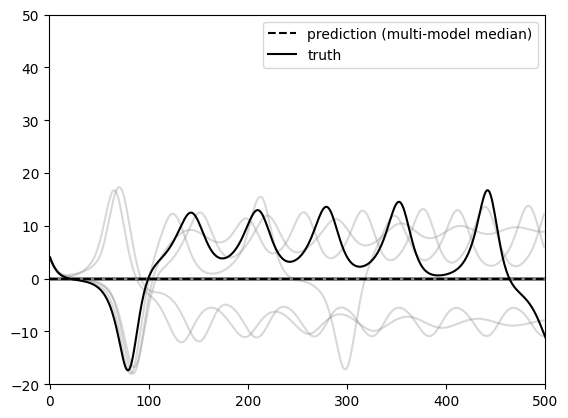

In [43]:
plt.figure()
plt.plot(predict[0,:,:].T,'gray',alpha=0.3)
plt.plot(np.median(predict[0,:,:],axis=0),'k--',label='prediction (multi-model median)')
plt.plot(data[0,7000:],'k',label='truth')
plt.legend()
plt.ylim([-20,50])
plt.xlim([-1,500])
